# Classification DPE — Performant / Passable / Energivore
## Pipeline Boosting (AdaBoost, Gradient Boosting, XGBoost)

**Entree :** `data_for_processing_final.xlsx` — la colonne `etiquette_dpe` contient directement
les 3 groupes cibles.

**Objectif :** entrainer et comparer trois algorithmes de boosting sur les memes donnees que les
autres notebooks du pipeline, afin de les confronter au Random Forest (meilleur modele du
pipeline jusqu'ici, F1 macro 0,788) et de voir si l'approche sequentielle du boosting apporte un
gain par rapport a l'approche parallele du bagging.

**Bagging vs Boosting (cf. cours, chapitre 9) :**
- Le **bagging** (Random Forest) entraine des modeles forts en parallele sur des echantillons
  bootstrap differents ; chaque modele est individuellement en situation de sur-apprentissage,
  et l'agregation reduit la variance de l'ensemble.
- Le **boosting** entraine des modeles faibles en sequence, chaque nouveau modele corrigeant les
  erreurs du precedent ; chaque modele est individuellement en situation de sous-apprentissage,
  et l'enchainement reduit le biais de l'ensemble.

**Les 3 algorithmes de ce notebook :**
- **AdaBoost** : a chaque iteration, le poids des observations mal classees par le predicteur
  precedent est augmente, pour que le predicteur suivant s'y concentre davantage.
- **Gradient Boosting** : a chaque iteration, un nouveau predicteur est entraine pour corriger
  l'erreur residuelle du predicteur precedent (et non plus en repondérant les observations).
- **XGBoost** : implementation optimisee du gradient boosting (regularisation supplementaire,
  parallelisation, gestion native des valeurs manquantes), tres utilisee en pratique.


**Plan du notebook :**
1. Imports et configuration
2. Chargement des donnees
3. Pretraitement
4. Split train / test
5. Pipeline et preprocesseur partage
6. AdaBoost
   - 6.1 Optimisation des hyperparametres (Optuna)
   - 6.2 Entrainement final
   - 6.3 Evolution des poids des observations
7. Gradient Boosting
   - 7.1 Optimisation des hyperparametres (Optuna)
   - 7.2 Entrainement final
   - 7.3 Effet du nombre d'iterations (n_estimators)
8. XGBoost
   - 8.1 Optimisation des hyperparametres (Optuna)
   - 8.2 Entrainement final
   - 8.3 Effet du nombre d'iterations (n_estimators)
9. Comparaison des 3 modeles de boosting
10. Evaluation des modeles
   - 10.1 Courbes d'apprentissage (train vs validation)
   - 10.2 Diagnostic de surapprentissage (accuracy)
   - 10.3 Matrice de confusion
   - 10.4 Rapport de classification (precision / rappel / F1 par classe)
   - 10.5 Courbes ROC et Precision-Rappel (one-vs-rest)
11. Diagnostics propres au boosting
   - 11.1 Importance des variables (Gini)
   - 11.2 Heatmap learning_rate x n_estimators (Gradient Boosting et XGBoost)
12. Conclusion


## 1. Imports et configuration



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    learning_curve, validation_curve
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from category_encoders import TargetEncoder

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline


####################################### A PARAMETRER ################################

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Les 3 groupes metier, directement disponibles dans la colonne cible
TARGET = "etiquette_dpe"
GROUPS = ["Performant", "Passable", "Energivore"]

GROUP_COLORS = {
    "Performant": "#00923F",
    "Passable":   "#F2C12B",
    "Energivore": "#E6442E",
}

N_TRIALS = 25  # nombre d'essais Optuna par modele

print("Imports OK")
print(f"  Cible : '{TARGET}' -> {GROUPS}")


Imports OK
  Cible : 'etiquette_dpe' -> ['Performant', 'Passable', 'Energivore']


## 2. Chargement des donnees

In [7]:
FILE_PATH = "resources/data_for_processing_final.xlsx"

df = pd.read_excel(FILE_PATH)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes totales : {df.isnull().sum().sum()}")

na_par_colonne = df.isnull().sum()
na_par_colonne = na_par_colonne[na_par_colonne > 0]
if len(na_par_colonne) > 0:
    print("\nColonnes concernees par des valeurs manquantes :")
    print(na_par_colonne)

vals = df[TARGET].unique()
print(f"\nValeurs uniques de '{TARGET}' : {sorted(vals)}")
print("Cible validee, les 3 groupes attendus sont presents")

print("\nDistribution de la cible :")
vc = df[TARGET].value_counts().reindex(GROUPS)
for grp, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {grp:<12} {cnt:6,}  ({pct:5.1f}%)  {bar}")

print(f"\nRatio de desequilibre : {vc.max() / vc.min():.1f}:1")


Dataset : 55,357 lignes x 25 colonnes
Valeurs manquantes totales : 9

Colonnes concernees par des valeurs manquantes :
configuration_installation_chauffage_n1    9
dtype: int64

Valeurs uniques de 'etiquette_dpe' : ['Energivore', 'Passable', 'Performant']
Cible validee, les 3 groupes attendus sont presents

Distribution de la cible :
  Performant    2,303  (  4.2%)  ##
  Passable     39,557  ( 71.5%)  ###################################
  Energivore   13,497  ( 24.4%)  ############

Ratio de desequilibre : 17.2:1


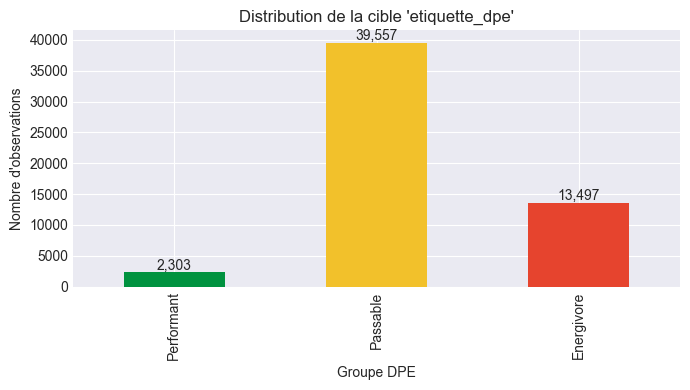

In [8]:
'''
Visualisation de la distribution de la cible. Sert a illustrer le desequilibre des
classes, deja constate ci-dessus, qui justifiera plus loin l'usage de poids de
classe (ou d'echantillon) plutot que la seule exactitude comme critere d'evaluation.
'''
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", color=[GROUP_COLORS[g] for g in vc.index], ax=ax)
ax.set_title("Distribution de la cible 'etiquette_dpe'")
ax.set_xlabel("Groupe DPE")
ax.set_ylabel("Nombre d'observations")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Pretraitement des donnees

In [9]:
def suppress_quasi_const(df):
    '''
    Supprime les colonnes quasi-constantes, c'est a dire les colonnes pour lesquelles
    une seule valeur represente plus de 95% des observations.

    Justification : une telle colonne n'apporte presque pas de variabilite au modele
    et se comporte essentiellement comme du bruit plutot que comme un signal utile.
    '''
    quasi_cst = [
        c for c in df.columns
        if c != TARGET
        and df[c].value_counts(normalize=True).iloc[0] > 0.95
    ]

    if quasi_cst:
        print(f"{'=' * 80}")
        print(f"Colonnes quasi-constantes supprimees ({len(quasi_cst)}) :")
        print(f"{'=' * 80}")
        for c in quasi_cst:
            top_val = df[c].value_counts(normalize=True).iloc[0]
            top_lab = df[c].value_counts().index[0]
            print(f"  {c:<50}  '{top_lab}' ({top_val:.1%})")
        df = df.drop(columns=quasi_cst)
    else:
        print(f"{'=' * 80}")
        print("Aucune colonne quasi-constante")
        print(f"{'=' * 80}")
    return df


def capping_outlier(df):
    '''
    Traitement des valeurs extremes :
    - hauteur_sous_plafond : ecretee (clip) a 6 metres, valeur jugee physiquement
      raisonnable pour un logement, au dela on considere une erreur de saisie.
    - colonnes a forte proportion de zeros (stockage ECS, production PV) : transformation
      log1p pour reduire l'asymetrie de la distribution sans perdre l'information des zeros.
    '''
    if "hauteur_sous_plafond" in df.columns:
        n = (df["hauteur_sous_plafond"] > 6.0).sum()
        df["hauteur_sous_plafond"] = df["hauteur_sous_plafond"].clip(upper=6.0)
        print(f"hauteur_sous_plafond clippee a 6m ({n} valeurs corrigees)")

    for col in ["volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            print(f"{col} -> log1p")

    print(f"\n{'=' * 80}")
    print(f"Dataset apres nettoyage : {df.shape[0]:,} x {df.shape[1]}")
    print(f"{'=' * 80}")
    return df

def encoding_ordinal(df):
    ordinal_vars = {
        'qualite_isolation_enveloppe':   ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_murs':        ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_menuiseries':  ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_plancher_bas': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'classe_inertie_batiment':        ['Légère', 'Moyenne', 'Lourde', 'Très lourde'],
        'periode_construction':           ['ancien', 'transition', 'moderne', 'recent', 'tres_recent'],
    }

    for col, order in ordinal_vars.items():
        if col not in df.columns:
            continue
        vals_in_data = set(df[col].dropna().unique())
        vals_in_order = set(order)
        unexpected = vals_in_data - vals_in_order
        if unexpected:
            print(f"⚠️  {col}: valeurs non prévues dans l'ordre → {unexpected}")
            for uv in unexpected:
                order.append(uv)

        mapping = {v: i for i, v in enumerate(order)}
        df[col + '_enc'] = df[col].map(mapping)
        n_nan = df[col + '_enc'].isnull().sum()
        print(f"{col} → encodé ({len(order)} niveaux, {n_nan} NaN)")

    # Suppression des colonnes d'origine, une fois encodées
    df = df.drop(columns=list(ordinal_vars.keys()))
    return df   # <-- la ligne qui manquait




In [10]:
def classe_features(df):
    '''
    Classe les colonnes du dataframe en 4 groupes selon le traitement qu'elles
    recevront dans le preprocesseur :
    - ordinal_enc_cols  : deja encodees en amont (suffixe '_enc'), passees telles quelles.
    - binary_cols       : variables binaires, passees telles quelles.
    - quant_cols        : variables numeriques continues, a mettre a l'echelle.
    - qual_cols         : variables qualitatives nominales restantes, a encoder (TargetEncoder).
    '''
    ordinal_enc_cols = [c for c in df.columns if c.endswith("_enc")]

    binary_cols = [c for c in ["ventilation_posterieure_2012"] if c in df.columns]

    base_num = ["hauteur_sous_plafond", "volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]
    quant_cols = [c for c in base_num if c in df.columns]

    exclude = [TARGET] + ordinal_enc_cols + binary_cols + quant_cols
    qual_cols = [
        c for c in df.columns
        if c not in exclude
        and (df[c].dtype == object or str(df[c].dtype) == "str")
    ]

    passthrough_cols = ordinal_enc_cols + binary_cols
    all_features = quant_cols + qual_cols + passthrough_cols

    print(f"\n{'=' * 40} Features pour le modele {'=' * 40}")
    print(f"Features totales : {len(all_features)}")
    print(f"  Numeriques   ({len(quant_cols)}) : {quant_cols}")
    print(f"  Qualitatives ({len(qual_cols)})")
    print(f"  Passthrough  ({len(passthrough_cols)})")
    print(f"{'=' * 80}")

    return all_features, quant_cols, qual_cols, passthrough_cols


def preprocessing(df):
    '''Enchaine les 3 etapes de nettoyage / classement des colonnes.'''
    df_suppr_quasi_const = suppress_quasi_const(df)
    df_process = capping_outlier(df_suppr_quasi_const)
    df_process_ordinal = encoding_ordinal(df_process)
    all_features, quant_cols, qual_cols, passthrough_cols = classe_features(df_process_ordinal)
    return df_process_ordinal, all_features, quant_cols, qual_cols, passthrough_cols


In [11]:
df_data, all_features, quant_cols, qual_cols, passthrough_cols = preprocessing(df)


Colonnes quasi-constantes supprimees (6) :
  zone_climatique                                     'H1a' (99.9%)
  classe_altitude                                     'inférieur à 400m' (100.0%)
  configuration_installation_chauffage_n1             'standard' (99.7%)
  configuration_installation_ecs_n1                   'Un seul système d'ECS sans solaire' (98.7%)
  type_installation_solaire_n1                        'Non affecté' (99.3%)
  production_electricite_pv_kwhep_par_an              '0.0' (98.9%)
hauteur_sous_plafond clippee a 6m (20 valeurs corrigees)
volume_stockage_generateur_n1_ecs_n1 -> log1p

Dataset apres nettoyage : 55,357 x 19
qualite_isolation_enveloppe → encodé (4 niveaux, 0 NaN)
qualite_isolation_murs → encodé (4 niveaux, 0 NaN)
qualite_isolation_menuiseries → encodé (4 niveaux, 0 NaN)
qualite_isolation_plancher_bas → encodé (4 niveaux, 0 NaN)
classe_inertie_batiment → encodé (4 niveaux, 0 NaN)
periode_construction → encodé (5 niveaux, 0 NaN)

=======================

## 4. Split train / test

In [12]:
'''
Separation stratifiee train/test (80/20). La stratification garantit que la
proportion des 3 groupes DPE reste identique entre train et test, ce qui est
indispensable ici puisque les classes sont fortement desequilibrees (cf. section 2).
'''
X = df_data[all_features].copy()
y = df_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print()
print("Distribution train :")
for grp in GROUPS:
    cnt = (y_train == grp).sum()
    pct = cnt / len(y_train) * 100
    print(f"  {grp:<12} {cnt:6,}  ({pct:.1f}%)")

print("\nVerification de la stratification :")
for grp in GROUPS:
    p_tr = (y_train == grp).mean() * 100
    p_te = (y_test == grp).mean() * 100
    delta = abs(p_tr - p_te)
    flag = "OK" if delta < 1.0 else "ATTENTION"
    print(f"  {grp:<12} train={p_tr:.1f}%  test={p_te:.1f}%  delta={delta:.2f}%  {flag}")


Train : 44,285  |  Test : 11,072

Distribution train :
  Performant    1,842  (4.2%)
  Passable     31,645  (71.5%)
  Energivore   10,798  (24.4%)

Verification de la stratification :
  Performant   train=4.2%  test=4.2%  delta=0.00%  OK
  Passable     train=71.5%  test=71.5%  delta=0.00%  OK
  Energivore   train=24.4%  test=24.4%  delta=0.01%  OK


**Pas de sous-echantillonnage necessaire ici.** Comme pour l'arbre de decision et le Random
Forest, les algorithmes de boosting passent bien a l'echelle : toutes les etapes de ce notebook
sont effectuees directement sur l'integralite de `X_train` / `y_train`.

**Note sur les poids de classe** : `AdaBoostClassifier` et `GradientBoostingClassifier` ne
disposent pas du parametre `class_weight` (a la difference de `LogisticRegression`, `SVC`,
`DecisionTreeClassifier` et `RandomForestClassifier` dans les notebooks precedents). Le
desequilibre des classes est gere ici via un `sample_weight` calcule manuellement et passe a
`fit()`, ce qui revient au meme principe mais avec une API differente. `XGBClassifier` accepte
egalement `sample_weight`.

**Note sur XGBoost et le format de la cible** : contrairement aux classifieurs scikit-learn
utilises dans ce notebook (qui acceptent directement des labels textuels), `XGBClassifier`
exige une cible encodee en entiers consecutifs (0, 1, 2, ...). Un `LabelEncoder` est donc
applique uniquement pour les sections concernant XGBoost, en figeant l'ordre des classes sur
celui de `GROUPS` pour rester coherent avec le reste du notebook.

In [13]:
'''
Encodage de la cible en entiers, necessaire uniquement pour XGBClassifier. L'ordre des classes
est fixe explicitement sur GROUPS (et non l'ordre alphabetique par defaut d'un LabelEncoder),
pour eviter tout desalignement ulterieur entre les predictions et les libelles textuels.
'''
label_encoder = LabelEncoder()
label_encoder.fit(GROUPS)

y_train_enc = pd.Series(label_encoder.transform(y_train), index=y_train.index)
y_test_enc = pd.Series(label_encoder.transform(y_test), index=y_test.index)

print(f"Classes encodees : {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


Classes encodees : {np.str_('Energivore'): np.int64(0), np.str_('Passable'): np.int64(1), np.str_('Performant'): np.int64(2)}


In [14]:
def make_sample_weight(y, weight_performant, weight_energivore):
    '''
    Construit un vecteur de poids par observation, equivalent a un class_weight, pour les
    modeles de ce notebook qui n'exposent pas directement ce parametre. Passable garde un
    poids de reference de 1.
    '''
    weights_map = {"Performant": weight_performant, "Passable": 1, "Energivore": weight_energivore}
    return y.map(weights_map).values


## 5. Pipeline et preprocesseur partage

Le meme `make_preprocessor()` est utilise pour les 3 modeles de boosting, afin de garantir une
comparaison strictement equitable, et de rester coherent avec les notebooks precedents.

In [15]:
def make_preprocessor():
    '''
    Construit le ColumnTransformer partage par les 3 modeles de ce notebook :
    - num  : variables numeriques continues, passees sans mise a l'echelle (les modeles a base
      d'arbres ne sont pas sensibles a l'echelle des variables).
    - cat  : TargetEncoder sur les variables qualitatives. Remplace chaque modalite par une
      statistique liee a la cible plutot que de creer une colonne par modalite.
    - pass : variables deja encodees ou binaires, passees sans transformation.
    '''
    cat_tr = TargetEncoder(smoothing=3.0, min_samples_leaf=50)

    transformers = [("num", "passthrough", quant_cols)]
    if qual_cols:
        transformers.append(("cat", cat_tr, qual_cols))
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator):
    '''Encapsule un estimateur quelconque dans le pipeline de preprocessing partage.'''
    return Pipeline([
        ("pre", make_preprocessor()),
        ("clf", estimator),
    ])


print("make_preprocessor() et make_model_pipeline() definis")


make_preprocessor() et make_model_pipeline() definis


In [16]:
def make_callback(n_trials, label="Optuna"):
    '''
    Construit un callback Optuna affichant la progression de l'optimisation :
    barre de progression, score du dernier essai, meilleur score trouve, temps
    ecoule et temps restant estime (ETA).
    '''
    scores = []
    t0 = [time.time()]

    def cb(study, trial):
        if trial.value is None:
            return
        scores.append(trial.value)
        best = study.best_value
        done = len(scores)
        elapsed = time.time() - t0[0]
        eta = (elapsed / done) * (n_trials - done)
        pct = done / n_trials
        bar = "#" * int(30 * pct) + "-" * (30 - int(30 * pct))

        print(f"\r[{label}] [{bar}] {done:>3}/{n_trials} ({pct * 100:5.1f}%)  "
              f"f1_macro={trial.value:.5f}  meilleur={best:.5f}  "
              f"ecoule={elapsed / 60:.1f}min  eta={eta / 60:.1f}min", end="")

        if done == n_trials:
            print(f"\nTermine. Meilleur f1_macro CV : {best:.5f}")
    return cb


trained_models = {}


def predict_labels(model, X):
    '''
    Predit les labels textuels pour un modele du pipeline, quel que soit son format de sortie
    natif. XGBoost a ete entraine sur une cible encodee en entiers (cf. section 4) et renvoie
    donc des entiers : on les redecode via label_encoder pour les comparer aux autres modeles,
    qui renvoient directement des labels textuels.
    '''
    y_pred = model.predict(X)
    if np.issubdtype(np.asarray(y_pred).dtype, np.integer):
        return label_encoder.inverse_transform(y_pred)
    return y_pred


def predict_proba_aligned(model, X):
    '''
    Predit les probabilites pour un modele du pipeline et reordonne les colonnes selon l'ordre
    de GROUPS. Gere a la fois les modeles dont les classes sont des labels textuels et XGBoost
    dont les classes sont des entiers encodes (cf. section 4).
    '''
    y_proba_raw = model.predict_proba(X)
    raw_classes = list(model.classes_)
    if np.issubdtype(np.asarray(raw_classes).dtype, np.integer):
        raw_classes = list(label_encoder.inverse_transform(raw_classes))
    reorder_idx = [raw_classes.index(grp) for grp in GROUPS]
    return y_proba_raw[:, reorder_idx]


## 6. AdaBoost

AdaBoost entraine sequentiellement des predicteurs faibles (par defaut, des arbres de decision
tres peu profonds, des "stumps"). A chaque iteration, le poids des observations mal classees par
le predicteur precedent est augmente, pour que le predicteur suivant s'y concentre davantage.

### 6.1 Optimisation des hyperparametres (Optuna)

Hyperparametres optimises :
- `n_estimators` : nombre de predicteurs sequentiels.
- `learning_rate` : limite la contribution de chaque predicteur a la decision finale.
- Poids d'echantillon (`weight_Performant`, `weight_Energivore`) : optimises conjointement, car
  le jeu de donnees est fortement desequilibre.

In [17]:
def objective_ada(trial):
    '''
    Fonction objectif Optuna pour AdaBoost.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    sw_train = make_sample_weight(y_train, weight_perf, weight_ener)

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 500, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 2.0, log=True),
    )
    pipeline = make_model_pipeline(
        AdaBoostClassifier(**params, random_state=RANDOM_STATE)
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw_train}
    )
    return scores.mean()


study_ada = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_adaboost",
)
study_ada.optimize(
    objective_ada, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "AdaBoost")]
)


[AdaBoost] [##############################]  25/25 (100.0%)  f1_macro=0.67077  meilleur=0.69844  ecoule=15.2min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.69844


### 6.2 Entrainement final

In [18]:
'''
Entrainement final d'AdaBoost avec les meilleurs hyperparametres trouves par Optuna, sur
l'integralite du train set.
'''
print("Entrainement final - AdaBoost...")
t0 = time.time()

ada_best_params = study_ada.best_params.copy()
weight_perf = ada_best_params.pop("weight_Performant")
weight_ener = ada_best_params.pop("weight_Energivore")
ADA_SAMPLE_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}
sw_train_ada = make_sample_weight(y_train, weight_perf, weight_ener)

model_ada = make_model_pipeline(
    AdaBoostClassifier(**ada_best_params, random_state=RANDOM_STATE)
)
model_ada.fit(X_train, y_train, clf__sample_weight=sw_train_ada)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_ada.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")
print(f"Hyperparametres retenus : {ada_best_params}")

trained_models["AdaBoost"] = model_ada


Entrainement final - AdaBoost...
Entraine en 26.3s
Meilleur f1_macro CV : 0.69844
Poids retenus -> Performant:3  Passable:1  Energivore:1
Hyperparametres retenus : {'n_estimators': 300, 'learning_rate': 0.4115089250932267}


### 6.3 Evolution des poids des observations

AdaBoost augmente le poids des observations mal classees a chaque iteration. Cette cellule
visualise comment les poids des observations se sont deplaces entre le debut et la fin de
l'entrainement, en illustration directe du mecanisme decrit dans le cours.

Le poids final de chaque observation est disponible sur l'attribut `estimator_weights_` combine
a l'erreur de chaque predicteur (`estimator_errors_`) ; ce qui est trace ici est l'evolution de
l'erreur ponderee au fil des iterations, qui refl ete indirectement comment la difficulte des
observations restantes evolue au fil de l'entrainement.

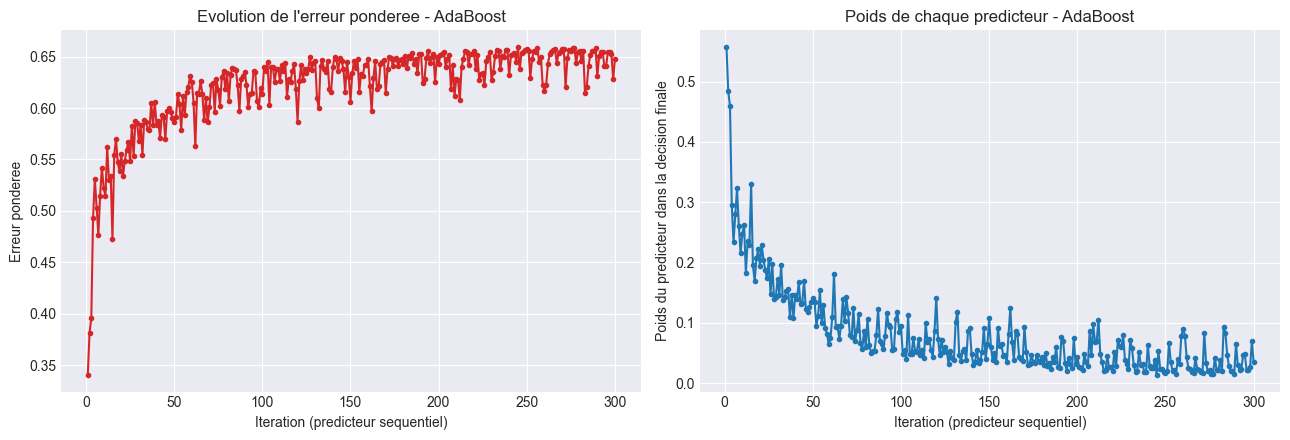

In [19]:
'''
Trace l'evolution de l'erreur ponderee de chaque predicteur sequentiel d'AdaBoost
(estimator_errors_) et du poids attribue a chaque predicteur dans la decision finale
(estimator_weights_). Une erreur ponderee qui reste basse indique que chaque nouveau
predicteur reste relativement competent malgre la concentration croissante sur les
observations difficiles.
'''
clf_ada = model_ada.named_steps["clf"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(1, len(clf_ada.estimator_errors_) + 1), clf_ada.estimator_errors_,
             "o-", color="#d62728", markersize=3)
axes[0].set_xlabel("Iteration (predicteur sequentiel)")
axes[0].set_ylabel("Erreur ponderee")
axes[0].set_title("Evolution de l'erreur ponderee - AdaBoost")

axes[1].plot(range(1, len(clf_ada.estimator_weights_) + 1), clf_ada.estimator_weights_,
             "o-", color="#1f77b4", markersize=3)
axes[1].set_xlabel("Iteration (predicteur sequentiel)")
axes[1].set_ylabel("Poids du predicteur dans la decision finale")
axes[1].set_title("Poids de chaque predicteur - AdaBoost")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On remarque que l'erreur ponderee des predicteurs grimpe tres vite et se stabilise autour de
0,60-0,65 a partir d'une cinquantaine d'iterations, ce qui est proche de l'erreur d'un tirage
aleatoire sur un probleme a 3 classes. En parallele, le poids attribue a chaque predicteur dans
la decision finale s'effondre tres rapidement (de 0,55 au debut a moins de 0,05 apres 50
iterations). Ça veut dire que la grande majorite des 300 predicteurs entraines ne contribuent
quasiment plus a la decision finale : seuls les tout premiers comptent vraiment. Ça explique
en partie la performance plus faible d'AdaBoost par rapport aux deux autres modeles de
boosting.

## 7. Gradient Boosting

Le Gradient Boosting entraine egalement des predicteurs sequentiels, mais au lieu de modifier
les poids des observations comme AdaBoost, chaque nouveau predicteur est entraine pour predire
directement l'erreur residuelle du predicteur precedent (cf. cours, chapitre 9).

### 7.1 Optimisation des hyperparametres (Optuna)

Hyperparametres optimises (cf. cours, page 28) :
- `n_estimators` : nombre d'arbres sequentiels.
- `learning_rate` : limite la contribution de chaque arbre.
- `max_depth` : profondeur de chaque arbre (les arbres de boosting sont generalement peu
  profonds, contrairement aux arbres du Random Forest).
- `subsample` : pourcentage d'observations utilise pour entrainer chaque arbre.
- Poids d'echantillon : optimises conjointement.

In [20]:
def objective_gb(trial):
    '''
    Fonction objectif Optuna pour le Gradient Boosting.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    sw_train = make_sample_weight(y_train, weight_perf, weight_ener)

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
    )
    pipeline = make_model_pipeline(
        GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw_train}
    )
    return scores.mean()


study_gb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_gradient_boosting",
)
study_gb.optimize(
    objective_gb, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Gradient Boosting")]
)


[Gradient Boosting] [##############################]  25/25 (100.0%)  f1_macro=0.77261  meilleur=0.77261  ecoule=22.3min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.77261


### 7.2 Entrainement final

In [21]:
'''
Entrainement final du Gradient Boosting avec les meilleurs hyperparametres trouves par
Optuna, sur l'integralite du train set.
'''
print("Entrainement final - Gradient Boosting...")
t0 = time.time()

gb_best_params = study_gb.best_params.copy()
weight_perf = gb_best_params.pop("weight_Performant")
weight_ener = gb_best_params.pop("weight_Energivore")
GB_SAMPLE_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}
sw_train_gb = make_sample_weight(y_train, weight_perf, weight_ener)

model_gb = make_model_pipeline(
    GradientBoostingClassifier(**gb_best_params, random_state=RANDOM_STATE)
)
model_gb.fit(X_train, y_train, clf__sample_weight=sw_train_gb)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_gb.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")
print(f"Hyperparametres retenus : {gb_best_params}")

trained_models["Gradient Boosting"] = model_gb


Entrainement final - Gradient Boosting...
Entraine en 54.6s
Meilleur f1_macro CV : 0.77261
Poids retenus -> Performant:6  Passable:1  Energivore:5
Hyperparametres retenus : {'n_estimators': 400, 'learning_rate': 0.11602098212789926, 'max_depth': 7, 'subsample': 0.7040637250860652}


### 7.3 Effet du nombre d'iterations (n_estimators)

A la difference du Random Forest, ou ajouter des arbres ne peut pas degrader la performance
(simple moyenne de modeles independants), le boosting peut recommencer a sur-apprendre si on
ajoute trop d'iterations : chaque nouveau predicteur continue de corriger des erreurs de plus en
plus marginales, jusqu'a s'ajuster au bruit des donnees d'entrainement. Cette courbe permet de
verifier si le nombre d'iterations retenu par Optuna se situe avant ou apres ce point.

n_estimators=10   f1_macro=0.7325
n_estimators=25   f1_macro=0.7490
n_estimators=50   f1_macro=0.7598
n_estimators=100  f1_macro=0.7663
n_estimators=150  f1_macro=0.7700
n_estimators=200  f1_macro=0.7716
n_estimators=300  f1_macro=0.7723
n_estimators=400  f1_macro=0.7726


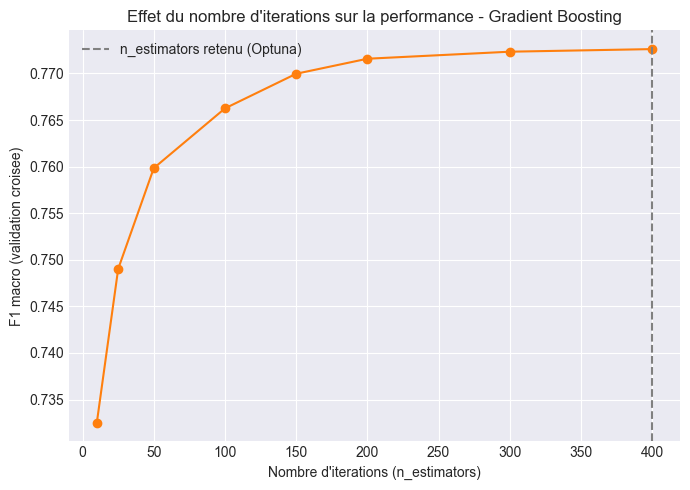

In [22]:
'''
Calcule le score F1 macro en validation croisee pour differentes valeurs de n_estimators,
toutes choses egales par ailleurs (les autres hyperparametres sont fixes a leur valeur
optimale trouvee par Optuna).
'''
n_estimators_range = np.array([10, 25, 50, 100, 150, 200, 300, 400])

gb_params_fixed = {k: v for k, v in gb_best_params.items() if k != "n_estimators"}

scores_n_estimators_gb = []
for n_est in n_estimators_range:
    pipeline = make_model_pipeline(
        GradientBoostingClassifier(n_estimators=n_est, **gb_params_fixed, random_state=RANDOM_STATE)
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw_train_gb}
    )
    scores_n_estimators_gb.append(scores.mean())
    print(f"n_estimators={n_est:<4} f1_macro={scores_n_estimators_gb[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_estimators_range, scores_n_estimators_gb, "o-", color="#ff7f0e")
ax.axvline(gb_best_params["n_estimators"], linestyle="--", color="gray",
           label="n_estimators retenu (Optuna)")
ax.set_xlabel("Nombre d'iterations (n_estimators)")
ax.set_ylabel("F1 macro (validation croisee)")
ax.set_title("Effet du nombre d'iterations sur la performance - Gradient Boosting")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le score progresse vite jusqu'a 100 iterations, puis atteint un plateau quasi parfait a partir
de 150-200. Le n_estimators retenu par Optuna (400) se situe en plein dans ce plateau, donc on
n'observe pas de degradation meme avec beaucoup d'iterations, sur cette plage testee.

## 8. XGBoost

XGBoost est une implementation optimisee du gradient boosting, avec une regularisation
supplementaire (L1/L2 sur les feuilles), une parallelisation de la construction des arbres, et
une gestion native des valeurs manquantes. Le principe sequentiel reste le meme que pour le
Gradient Boosting de scikit-learn.

### 8.1 Optimisation des hyperparametres (Optuna)

Hyperparametres optimises (analogues a ceux du Gradient Boosting, avec en plus la
regularisation propre a XGBoost) :
- `n_estimators`, `learning_rate`, `max_depth`, `subsample` : memes hyperparametres que pour le
  Gradient Boosting, pour rester comparable.
- `reg_lambda` : regularisation L2 sur les poids des feuilles, specifique a XGBoost.
- Poids d'echantillon : optimises conjointement.

In [23]:
def objective_xgb(trial):
    '''
    Fonction objectif Optuna pour XGBoost.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    sw_train = make_sample_weight(y_train, weight_perf, weight_ener)

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    pipeline = make_model_pipeline(
        XGBClassifier(
            **params,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train_enc,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw_train}
    )
    return scores.mean()


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_xgboost",
)
study_xgb.optimize(
    objective_xgb, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "XGBoost")]
)


[XGBoost] [##############################]  25/25 (100.0%)  f1_macro=0.76445  meilleur=0.77462  ecoule=2.3min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.77462


### 8.2 Entrainement final

In [24]:
'''
Entrainement final de XGBoost avec les meilleurs hyperparametres trouves par Optuna, sur
l'integralite du train set.
'''
print("Entrainement final - XGBoost...")
t0 = time.time()

xgb_best_params = study_xgb.best_params.copy()
weight_perf = xgb_best_params.pop("weight_Performant")
weight_ener = xgb_best_params.pop("weight_Energivore")
XGB_SAMPLE_WEIGHT = {"Performant": weight_perf, "Passable": 1, "Energivore": weight_ener}
sw_train_xgb = make_sample_weight(y_train, weight_perf, weight_ener)

model_xgb = make_model_pipeline(
    XGBClassifier(
        **xgb_best_params,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
model_xgb.fit(X_train, y_train_enc, clf__sample_weight=sw_train_xgb)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_xgb.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")
print(f"Hyperparametres retenus : {xgb_best_params}")

trained_models["XGBoost"] = model_xgb


Entrainement final - XGBoost...
Entraine en 1.7s
Meilleur f1_macro CV : 0.77462
Poids retenus -> Performant:2  Passable:1  Energivore:7
Hyperparametres retenus : {'n_estimators': 100, 'learning_rate': 0.24573358023499134, 'max_depth': 8, 'subsample': 0.8352842407287344, 'reg_lambda': 0.024515446272415007}


### 8.3 Effet du nombre d'iterations (n_estimators)

Meme logique que pour le Gradient Boosting (section 7.3) : verifier si le nombre d'iterations
retenu par Optuna se situe avant ou apres le point ou la performance en validation commence a
se degrader.

n_estimators=10   f1_macro=0.7460
n_estimators=25   f1_macro=0.7627
n_estimators=50   f1_macro=0.7685
n_estimators=100  f1_macro=0.7746
n_estimators=150  f1_macro=0.7759
n_estimators=200  f1_macro=0.7789
n_estimators=300  f1_macro=0.7789
n_estimators=400  f1_macro=0.7796


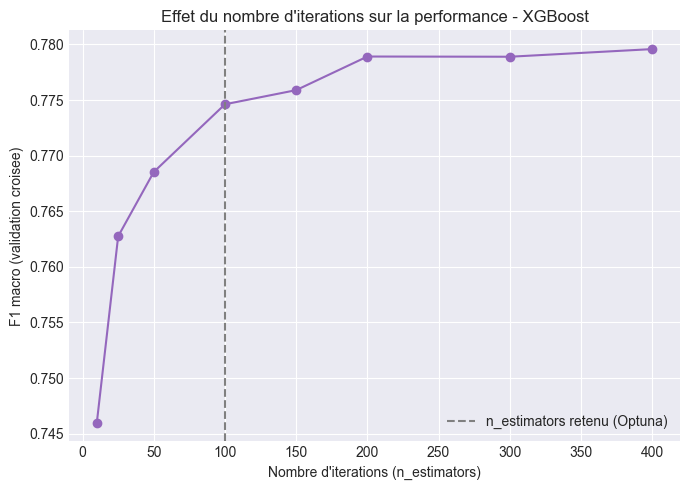

In [25]:
'''
Calcule le score F1 macro en validation croisee pour differentes valeurs de n_estimators,
toutes choses egales par ailleurs.
'''
xgb_params_fixed = {k: v for k, v in xgb_best_params.items() if k != "n_estimators"}

scores_n_estimators_xgb = []
for n_est in n_estimators_range:
    pipeline = make_model_pipeline(
        XGBClassifier(
            n_estimators=n_est, **xgb_params_fixed,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train_enc,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
        params={"clf__sample_weight": sw_train_xgb}
    )
    scores_n_estimators_xgb.append(scores.mean())
    print(f"n_estimators={n_est:<4} f1_macro={scores_n_estimators_xgb[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_estimators_range, scores_n_estimators_xgb, "o-", color="#9467bd")
ax.axvline(xgb_best_params["n_estimators"], linestyle="--", color="gray",
           label="n_estimators retenu (Optuna)")
ax.set_xlabel("Nombre d'iterations (n_estimators)")
ax.set_ylabel("F1 macro (validation croisee)")
ax.set_title("Effet du nombre d'iterations sur la performance - XGBoost")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Contrairement au Gradient Boosting, le score continue de progresser legerement jusqu'a 400
iterations, sans vraiment plafonner. Le n_estimators retenu par Optuna (100) se situe avant ce
plateau : on aurait peut-etre pu gagner un peu plus en autorisant Optuna a explorer au-dela de
400 iterations.

## 9. Comparaison des 3 modeles de boosting

Comparaison directe des trois algorithmes sur le test set

In [26]:
'''
Calcule, pour les 3 modeles entraines, les metriques de reference sur le test set :
accuracy, balanced accuracy et F1 macro.
'''
comparison_rows = []
for name, model in trained_models.items():
    y_pred = predict_labels(model, X_test)
    comparison_rows.append({
        "Modele":            name,
        "Accuracy":          accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro":          f1_score(y_test, y_pred, average="macro"),
    })

df_comparison = pd.DataFrame(comparison_rows).sort_values("F1 macro", ascending=False)
df_comparison = df_comparison.reset_index(drop=True)
print(df_comparison.to_string(index=False))
print(f"\nPour reference, Random Forest (notebook precedent) : F1 macro = 0.788")

BEST_MODEL_NAME = df_comparison.loc[0, "Modele"]
best_model = trained_models[BEST_MODEL_NAME]
print(f"\nModele retenu pour l'analyse detaillee : {BEST_MODEL_NAME}")


           Modele  Accuracy  Balanced Accuracy  F1 macro
Gradient Boosting  0.816022           0.826926  0.780290
          XGBoost  0.802023           0.818289  0.776852
         AdaBoost  0.803739           0.691889  0.705596

Pour reference, Random Forest (notebook precedent) : F1 macro = 0.788

Modele retenu pour l'analyse detaillee : Gradient Boosting


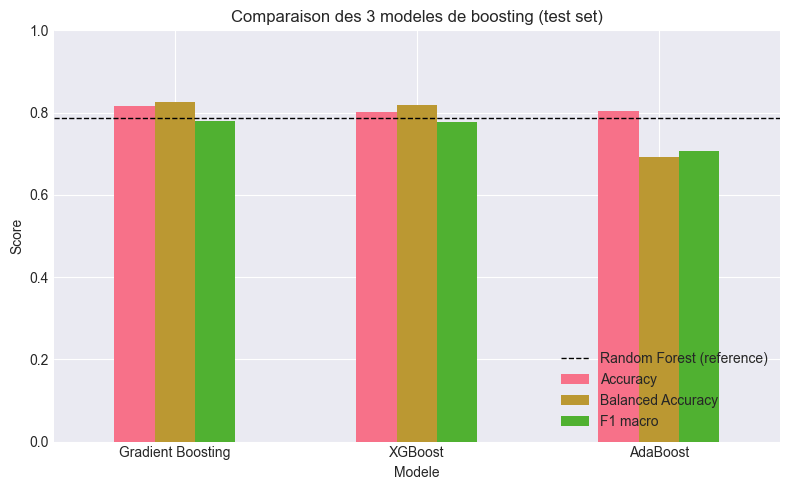

In [27]:
'''
Visualisation comparative des 3 modeles de boosting sur les 3 metriques de reference.
'''
fig, ax = plt.subplots(figsize=(8, 5))
df_plot = df_comparison.set_index("Modele")
df_plot.plot(kind="bar", ax=ax)
ax.axhline(0.788, linestyle="--", color="black", linewidth=1, label="Random Forest (reference)")
ax.set_title("Comparaison des 3 modeles de boosting (test set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Gradient Boosting arrive en tete avec un F1 macro de 0,780, suivi de tres pres par XGBoost
(0,777), et plus loin par AdaBoost (0,706). Les deux premiers restent legerement en dessous du
Random Forest du notebook precedent (0,788), donc sur ce probleme precis, le boosting n'apporte
pas de gain par rapport au bagging, malgre une approche bien plus sophistiquee. AdaBoost se
demarque nettement comme le moins bon des trois, ce qui colle avec ce qu'on a vu en section 6.3
sur l'effondrement rapide du poids des predicteurs.

## 10. Evaluation des modeles

Cette section reprend les outils de diagnostic generiques a tout classifieur, deja standardises
dans les notebooks precedents du pipeline, pour les 3 modeles de boosting.

### 10.1 Courbes d'apprentissage (train vs validation)

La courbe d'apprentissage montre l'evolution du score (F1 macro) sur le train set et sur le
validation set en fonction de la quantite de donnees d'entrainement utilisee, pour les 3
modeles.

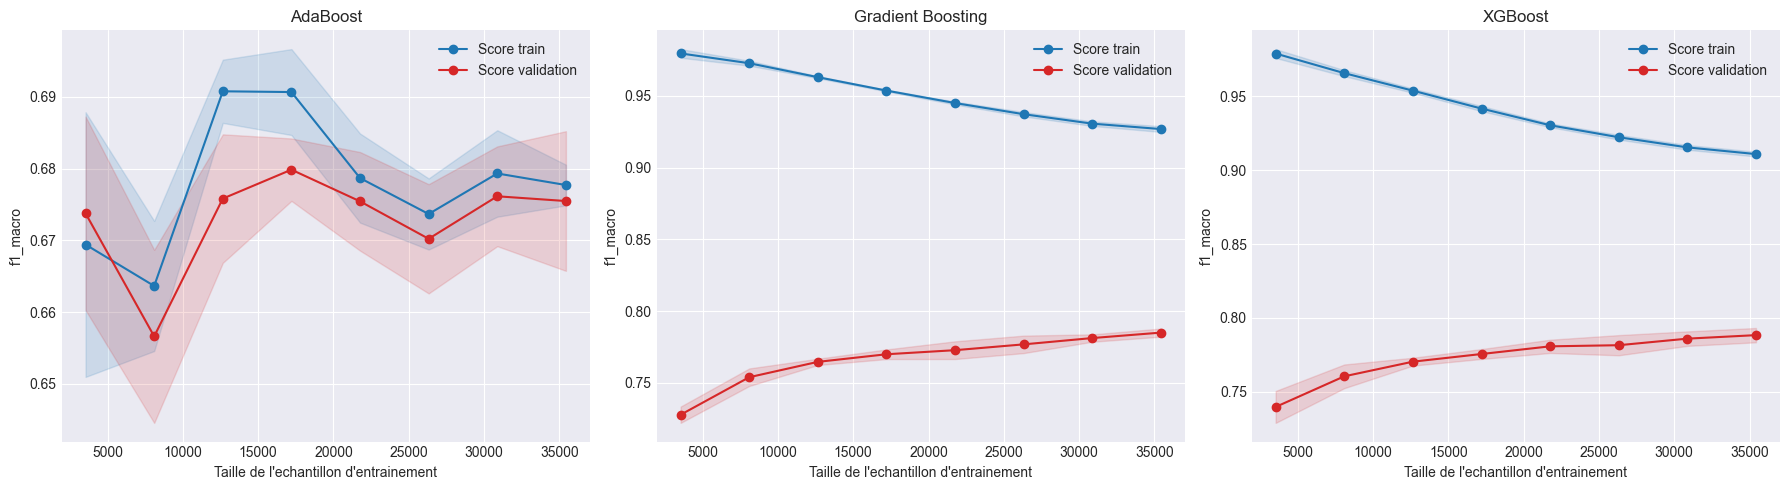

In [28]:
def plot_learning_curve(model, X, y, title, ax, cv=cv5, scoring="f1_macro"):
    '''
    Calcule et trace la courbe d'apprentissage d'un modele deja configure (pipeline
    complet avec son estimateur final), en utilisant la fonction learning_curve de
    scikit-learn. Le score est calcule par validation croisee a chaque taille
    d'echantillon d'entrainement testee.
    '''
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Score train", color="#1f77b4")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="#1f77b4")
    ax.plot(train_sizes, val_mean, "o-", label="Score validation", color="#d62728")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color="#d62728")

    ax.set_title(title)
    ax.set_xlabel("Taille de l'echantillon d'entrainement")
    ax.set_ylabel(scoring)
    ax.legend(loc="best")


'''
Note : learning_curve ne supporte pas directement le passage de sample_weight par taille
d'echantillon. Les courbes ci-dessous sont donc calculees sans ponderation des classes, a
titre de diagnostic de la forme generale (convergence, ecart train/validation), independamment
des poids retenus pour la performance finale. XGBoost utilise y_train_enc (cible encodee en
entiers), les deux autres modeles utilisent directement y_train (labels textuels).
'''
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_for_curve = y_train_enc if name == "XGBoost" else y_train
    plot_learning_curve(model, X_train, y_for_curve, name, ax)
plt.tight_layout()
plt.show()


### 10.2 Diagnostic de surapprentissage (accuracy)

Complement a la courbe d'apprentissage ci-dessus, base sur l'accuracy (et non le F1 macro), pour
les 3 modeles sur le meme graphique. Un seuil de surapprentissage est fixe arbitrairement a
0.10 : au-dela de cet ecart entre le score train et le score validation, on considere que le
modele apprend trop specifiquement les donnees d'entrainement.

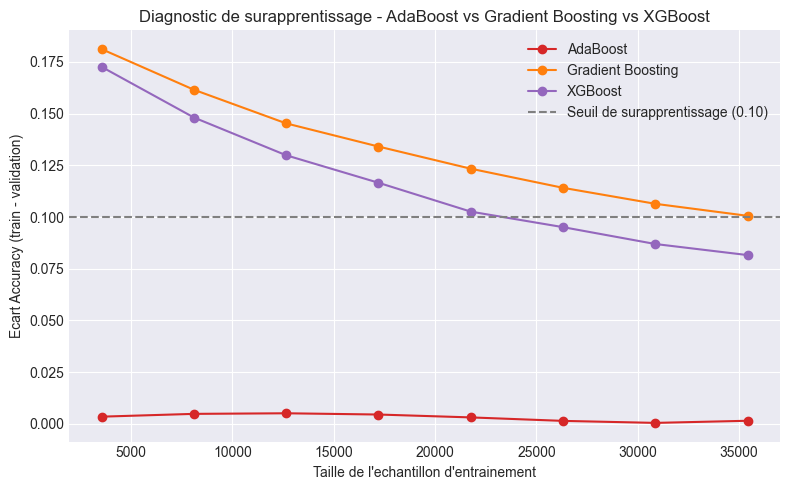

In [29]:
'''
Diagnostic de surapprentissage des 3 modeles, base sur l'accuracy. Meme remarque que pour la
courbe d'apprentissage : calcule sans ponderation des classes par souci de compatibilite avec
learning_curve.
'''
SEUIL_OVERFITTING = 0.10

couleurs_modeles = {
    "AdaBoost":          "#d62728",
    "Gradient Boosting": "#ff7f0e",
    "XGBoost":           "#9467bd",
}

fig, ax = plt.subplots(figsize=(8, 5))

for name, model in trained_models.items():
    y_for_curve = y_train_enc if name == "XGBoost" else y_train
    train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
        model, X_train, y_for_curve,
        cv=cv5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    ecart_train_val_acc = train_scores_acc.mean(axis=1) - val_scores_acc.mean(axis=1)
    couleur = couleurs_modeles.get(name, None)
    ax.plot(train_sizes_acc, ecart_train_val_acc, "o-", color=couleur, label=name)

ax.axhline(SEUIL_OVERFITTING, linestyle="--", color="gray",
           label=f"Seuil de surapprentissage ({SEUIL_OVERFITTING:.2f})")

ax.set_xlabel("Taille de l'echantillon d'entrainement")
ax.set_ylabel("Ecart Accuracy (train - validation)")
ax.set_title("Diagnostic de surapprentissage - AdaBoost vs Gradient Boosting vs XGBoost")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Gradient Boosting et XGBoost sur-apprennent fortement (ecart au-dessus du seuil de 0,10 sur une grande partie de la courbe), alors qu'AdaBoost reste extremement stable et largement sous le seuil (autour de 0,003). On remarque
que c'est exactement l'inverse de ce qu'on pourrait attendre du boosting en theorie (modeles
faibles qui reduisent le biais), mais ça colle avec les hyperparametres retenus par Optuna pour
GB et XGBoost (max_depth eleve, jusqu'a 7-8, donc des arbres individuels deja assez complexes,
pas vraiment des "weak learners"). XGBoost finit quand même par redescendre sous le seuil avec
le maximum de données, alors que Gradient Boosting y reste juste au-dessus.

### 10.3 Matrice de confusion

Une ligne par modele, pour comparer directement leurs erreurs de classement.

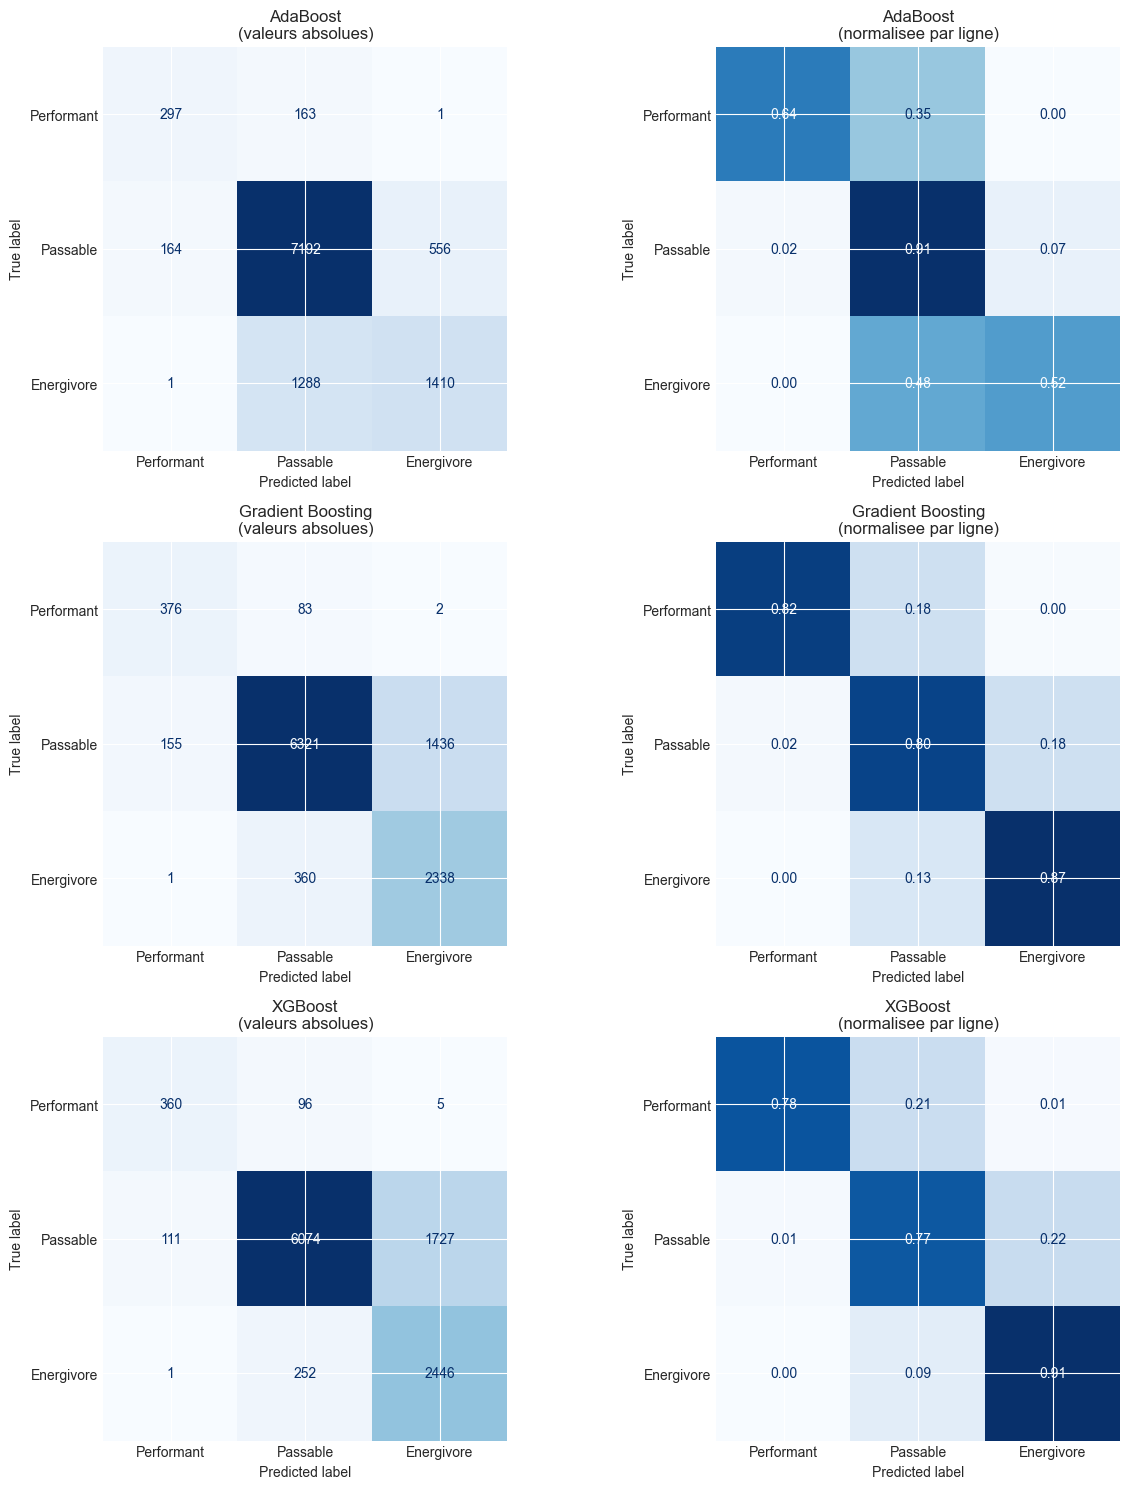

In [30]:
'''
Matrice de confusion des 3 modeles sur le test set, en valeurs absolues et normalisee
par ligne (taux de rappel par classe).
'''
fig, axes = plt.subplots(3, 2, figsize=(13, 15))

for row, (name, model) in enumerate(trained_models.items()):
    y_pred = predict_labels(model, X_test)

    cm = confusion_matrix(y_test, y_pred, labels=GROUPS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUPS)
    disp.plot(ax=axes[row, 0], cmap="Blues", colorbar=False)
    axes[row, 0].set_title(f"{name}\n(valeurs absolues)")

    cm_norm = confusion_matrix(y_test, y_pred, labels=GROUPS, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=GROUPS)
    disp_norm.plot(ax=axes[row, 1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[row, 1].set_title(f"{name}\n(normalisee par ligne)")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le profil d'AdaBoost se distingue nettement des deux autres : il rate beaucoup plus la classe
Energivore (52 % de rappel seulement, contre 87-91 % pour Gradient Boosting et XGBoost), avec
une grosse confusion vers Passable. Gradient Boosting et XGBoost ont des profils tres
similaires entre eux, avec une bonne detection des 3 classes (78-91 % de rappel selon la
classe). Comme dans tous les notebooks precedents, on ne voit jamais de confusion directe entre
Performant et Energivore.

### 10.4 Rapport de classification (precision / rappel / F1 par classe)

Rapport detaille pour les 3 modeles.

In [31]:
for name, model in trained_models.items():
    y_pred = predict_labels(model, X_test)
    print(f"Rapport de classification - {name}\n")
    print(classification_report(y_test, y_pred, target_names=GROUPS, digits=3))
    print()


Rapport de classification - AdaBoost

              precision    recall  f1-score   support

  Performant      0.717     0.522     0.604      2699
    Passable      0.832     0.909     0.869      7912
  Energivore      0.643     0.644     0.644       461

    accuracy                          0.804     11072
   macro avg      0.731     0.692     0.706     11072
weighted avg      0.796     0.804     0.795     11072


Rapport de classification - Gradient Boosting

              precision    recall  f1-score   support

  Performant      0.619     0.866     0.722      2699
    Passable      0.935     0.799     0.861      7912
  Energivore      0.707     0.816     0.757       461

    accuracy                          0.816     11072
   macro avg      0.753     0.827     0.780     11072
weighted avg      0.848     0.816     0.823     11072


Rapport de classification - XGBoost

              precision    recall  f1-score   support

  Performant      0.585     0.906     0.711      2699
    P

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Gradient Boosting et XGBoost ont un profil tres proche : bon rappel sur Performant (86-91 %)
mais precision plus faible (58-62 %), donc ils ont tendance a sur-predire cette classe
minoritaire. AdaBoost est plus equilibre sur Performant (precision 0,717, rappel 0,522) mais
nettement plus faible sur Energivore (F1 0,644 contre 0,757-0,772 pour les deux autres).

### 10.5 Courbes ROC et Precision-Rappel (one-vs-rest)

Une ligne par modele. Les colonnes de `predict_proba` sont reordonnees selon l'ordre de GROUPS,
car scikit-learn et XGBoost trient les classes dans l'ordre rencontre lors du fit (qui ne
correspond pas necessairement a l'ordre de GROUPS), ce qui fausserait les courbes sans ce
reordonnancement.

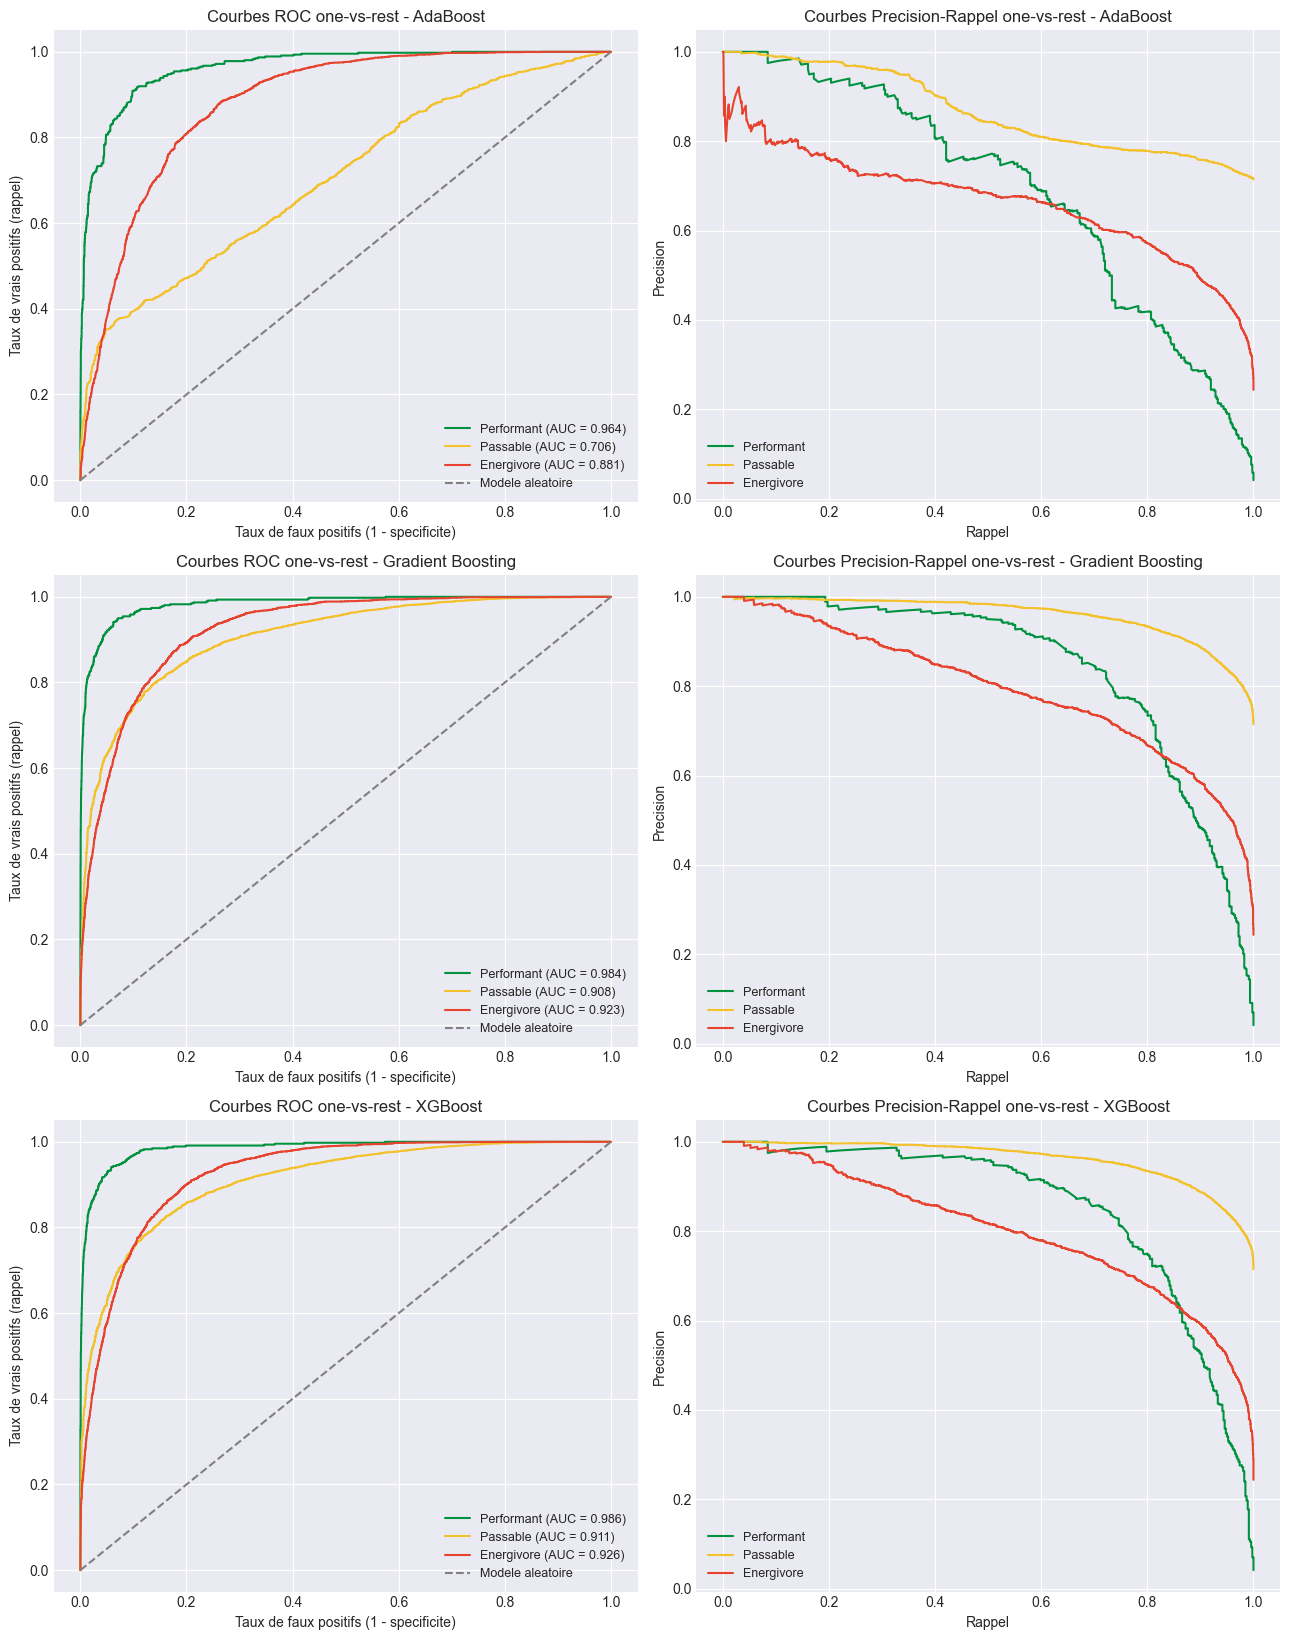

In [32]:
'''
Calcule les courbes ROC et Precision-Rappel pour chaque classe en one-vs-rest, pour les
3 modeles. Une ligne par modele.
'''
y_test_bin = label_binarize(y_test, classes=GROUPS)

fig, axes = plt.subplots(3, 2, figsize=(13, 16.5))

for row, (name, model) in enumerate(trained_models.items()):
    y_proba = predict_proba_aligned(model, X_test)

    for i, grp in enumerate(GROUPS):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[row, 0].plot(fpr, tpr, color=GROUP_COLORS[grp],
                           label=f"{grp} (AUC = {roc_auc:.3f})")
    axes[row, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire")
    axes[row, 0].set_xlabel("Taux de faux positifs (1 - specificite)")
    axes[row, 0].set_ylabel("Taux de vrais positifs (rappel)")
    axes[row, 0].set_title(f"Courbes ROC one-vs-rest - {name}")
    axes[row, 0].legend(loc="lower right", fontsize=9)

    for i, grp in enumerate(GROUPS):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
        axes[row, 1].plot(recall, precision, color=GROUP_COLORS[grp], label=grp)
    axes[row, 1].set_xlabel("Rappel")
    axes[row, 1].set_ylabel("Precision")
    axes[row, 1].set_title(f"Courbes Precision-Rappel one-vs-rest - {name}")
    axes[row, 1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

L'AUC d'AdaBoost pour Passable (0,706) est nettement plus faible que celle de Gradient
Boosting et XGBoost (0,908-0,911), ce qui confirme encore une fois la difficulte d'AdaBoost a
bien separer cette classe des deux autres. Pour Performant et Energivore, les trois modeles
restent proches et avec de bonnes AUC (0,88-0,99)

## 11. Diagnostics propres au boosting

Cette section regroupe les analyses qui n'ont pas d'equivalent dans les notebooks de regression
logistique et de SVM, et qui completent celles deja vues pour l'arbre/Random Forest.

### 11.1 Importance des variables (Gini)

Disponible nativement pour les 3 modeles (`feature_importances_`), comme pour l'arbre de
decision et le Random Forest du notebook precedent. Permet de verifier si les 3 algorithmes de
boosting s'accordent entre eux, et avec les modeles a base d'arbres deja vus, sur les variables
les plus determinantes.

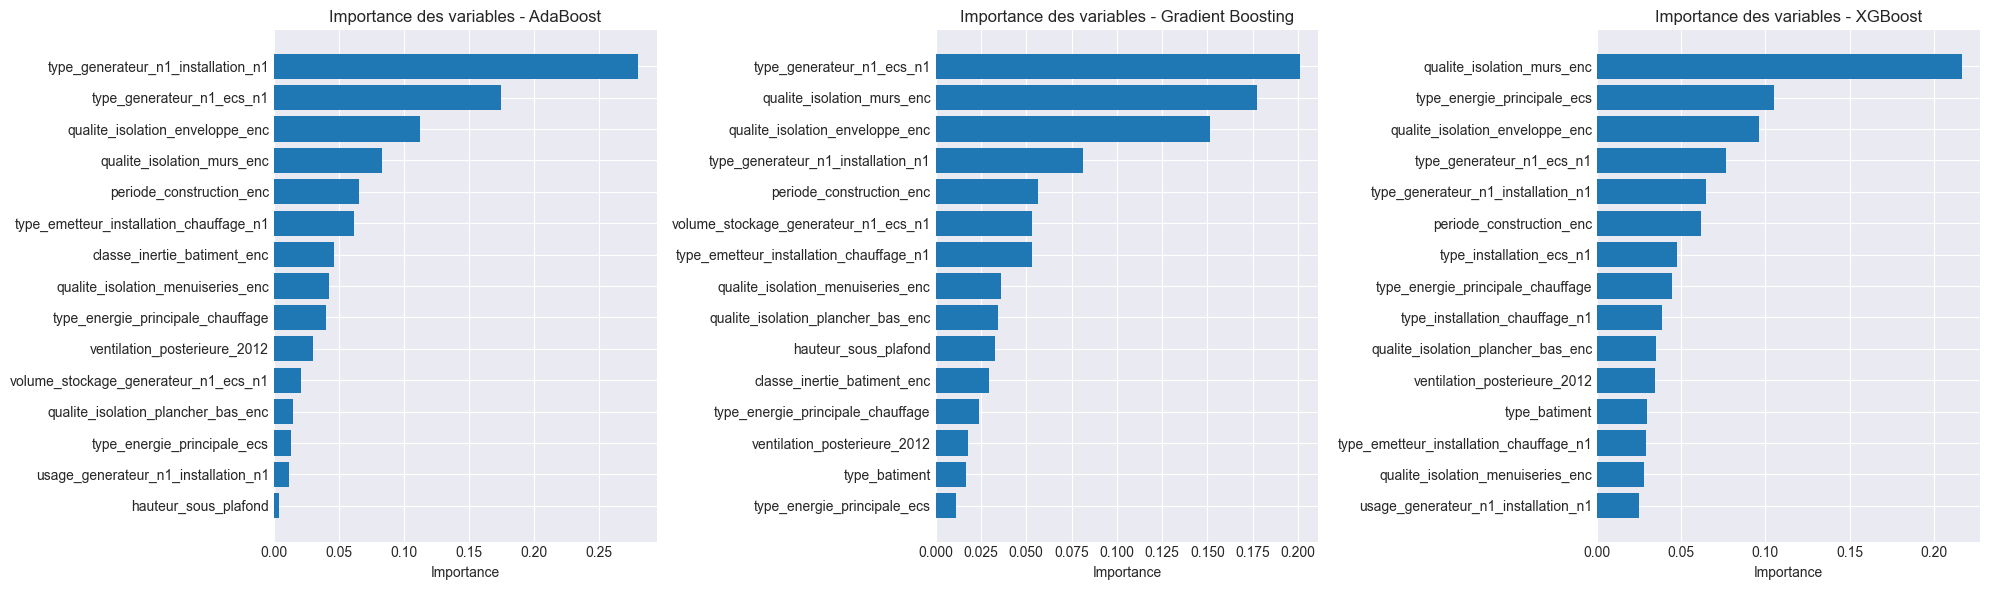

In [33]:
'''
Affiche les 15 variables les plus importantes pour chacun des 3 modeles, mesurees par la
reduction moyenne de l'impurete de Gini qu'elles apportent (ou le critere equivalent pour
XGBoost).
'''
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    feature_names = model.named_steps["pre"].get_feature_names_out()
    importances = model.named_steps["clf"].feature_importances_

    importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    ax.barh(importance_df.index[::-1], importance_df.values[::-1], color="#1f77b4")
    ax.set_title(f"Importance des variables - {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>


Les 3 modeles s'accordent globalement sur les variables les plus importantes :
`type_generateur_n1_ecs_n1`, `type_generateur_n1_installation_n1`, et les variables d'isolation
nouvellement encodees en ordinal (`qualite_isolation_murs_enc`, `qualite_isolation_enveloppe_enc`)
arrivent toutes en tete pour les 3 modeles. On remarque que XGBoost met `qualite_isolation_murs_enc`
en toute premiere position, alors que les deux autres modeles la placent plutot en 2e-3e
position derriere les variables de generateur. L'encodage ordinal ajoute semble bien capter de
l'information utile, puisque ces variables ressortent nettement plus haut que dans le notebook
Arbre/Random Forest precedent

### 11.2 Heatmap learning_rate x n_estimators

Le compromis entre `learning_rate` et `n_estimators` est central pour le Gradient Boosting et
XGBoost (cf. cours, page 28) : un learning_rate faible necessite davantage d'iterations pour
converger, mais generalise generalement mieux ; un learning_rate eleve converge plus vite mais
risque de sur-apprendre. Cette heatmap visualise ce compromis pour les deux modeles.

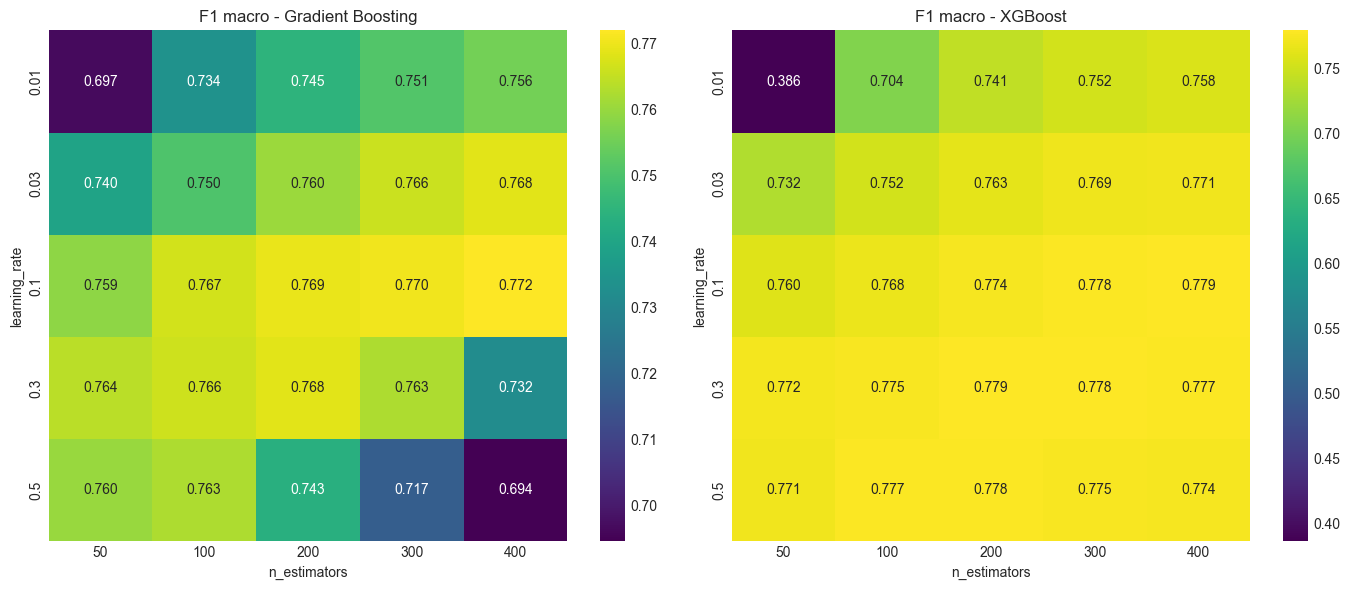

In [34]:
'''
Calcule le score F1 macro en validation croisee sur une grille (learning_rate, n_estimators),
pour le Gradient Boosting et XGBoost. Les autres hyperparametres sont fixes a leur valeur
optimale respective trouvee par Optuna.
'''
lr_grid = np.array([0.01, 0.03, 0.1, 0.3, 0.5])
n_est_grid = np.array([50, 100, 200, 300, 400])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gradient Boosting
gb_params_fixed_lr = {k: v for k, v in gb_best_params.items()
                       if k not in ("learning_rate", "n_estimators")}
heatmap_gb = np.zeros((len(lr_grid), len(n_est_grid)))
for i, lr in enumerate(lr_grid):
    for j, n_est in enumerate(n_est_grid):
        pipeline = make_model_pipeline(
            GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est,
                                        **gb_params_fixed_lr, random_state=RANDOM_STATE)
        )
        scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
            params={"clf__sample_weight": sw_train_gb}
        )
        heatmap_gb[i, j] = scores.mean()

sns.heatmap(heatmap_gb, xticklabels=n_est_grid, yticklabels=lr_grid,
            annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("learning_rate")
axes[0].set_title("F1 macro - Gradient Boosting")

# XGBoost
xgb_params_fixed_lr = {k: v for k, v in xgb_best_params.items()
                        if k not in ("learning_rate", "n_estimators")}
heatmap_xgb = np.zeros((len(lr_grid), len(n_est_grid)))
for i, lr in enumerate(lr_grid):
    for j, n_est in enumerate(n_est_grid):
        pipeline = make_model_pipeline(
            XGBClassifier(learning_rate=lr, n_estimators=n_est, **xgb_params_fixed_lr,
                          objective="multi:softprob", eval_metric="mlogloss",
                          random_state=RANDOM_STATE, n_jobs=-1)
        )
        scores = cross_val_score(
            pipeline, X_train, y_train_enc,
            cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0,
            params={"clf__sample_weight": sw_train_xgb}
        )
        heatmap_xgb[i, j] = scores.mean()

sns.heatmap(heatmap_xgb, xticklabels=n_est_grid, yticklabels=lr_grid,
            annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("learning_rate")
axes[1].set_title("F1 macro - XGBoost")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>
Pour Gradient Boosting, on voit tres bien le phenomene de degradation evoque dans le cours :
avec un learning_rate eleve (0,5) et beaucoup d'iterations (300-400), le score chute nettement
(jusqu'a 0,694, le pire score de toute la grille). Le meilleur compromis se situe plutot autour
de learning_rate=0,1-0,3 avec un nombre d'iterations eleve. Pour XGBoost, on ne voit pas ce meme
phenomene de degradation : le score reste stable ou continue de progresser legerement meme aux
valeurs elevees de learning_rate et n_estimators, ce qui montre que la regularisation
supplementaire de XGBoost (reg_lambda) protege mieux contre ce type de sur-apprentissage que le
Gradient Boosting classique.



## 12. Conclusion

On a teste trois algorithmes de boosting (AdaBoost, Gradient Boosting, XGBoost) sur le meme
probleme de classification du DPE. C'est **Gradient Boosting** qui obtient le meilleur F1 macro
(0,780), suivi de tres pres par XGBoost (0,777), AdaBoost restant nettement en retrait (0,706).

Aucun des trois ne depasse le Random Forest du notebook precedent (F1 macro 0,788) : sur ce
probleme precis, l'approche sequentielle du boosting n'apporte pas de gain par rapport a
l'approche parallele du bagging, malgre sa plus grande sophistication theorique.

On remarque aussi un resultat assez inattendu par rapport au cours : Gradient Boosting et
XGBoost sur-apprennent fortement (ecart train-validation au-dessus du seuil de 0,10 sur une
grande partie de la courbe), alors qu'AdaBoost reste tres stable. En theorie, le boosting
enchaine des modeles faibles pour reduire le biais, mais ici les hyperparametres retenus par
Optuna donnent des arbres individuels assez profonds (max_depth jusqu'a 7-8), ce qui les
rapproche plus de modeles forts que de vrais "weak learners". XGBoost finit quand meme par
repasser sous le seuil avec le maximum de donnees, contrairement a Gradient Boosting.

Les variables les plus importantes restent coherentes avec les notebooks precedents
(`type_generateur_n1_ecs_n1`, `type_generateur_n1_installation_n1`), avec en plus les variables
d'isolation nouvellement encodees en ordinal qui ressortent nettement mieux qu'avant.

Comme limites, on peut citer l'absence de calibration des probabilites, l'absence de
ponderation des classes dans les courbes d'apprentissage (sections 10.1/10.2, par contrainte
technique de `learning_curve`), et le sur-apprentissage de Gradient Boosting et XGBoost qui
pourrait probablement etre reduit en contraignant davantage `max_depth` dans une iteration
future.